# NowEDA Playground

This notebook demonstrates NowEDA's complete API in three sections:

1. **The 5 Powerful Methods** — Comprehensive analysis in one call
2. **The 10 One-Liner Methods** — Interactive exploration with format options
3. **The Plugin System** — Custom analysis workflows

---

## Setup

In [1]:
import noweda as eda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set pandas to display full DataFrame content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print('NowEDA imported successfully')

NowEDA imported successfully


## Load Your Data

Change the path to any file you want to test.

In [2]:
# --- CHANGE THIS PATH ---
FILE = 'test_data_large_with_pii.csv'
# ------------------------

df = eda.read(FILE)
print(f'Loaded: {len(df)} rows x {len(df.columns)} columns')
df.head()

Loaded: 100000 rows x 16 columns


,customer_id,first_name,last_name,email,phone,ssn,credit_card,account_balance,transaction_count,account_age_days,region,account_status,last_transaction,notes,signup_date,risk_score
0,1000000,Noah,Martinez,noah.martinez956@company.com,+1-963-543-6107,295-44-6327,NaN,7169.27,283,1825,Central,suspended,2025-10-30T21:47:06.543456,"Email: noah.martinez956@company.com, Follow up needed",2018-08-10T21:47:06.543467,7
1,1000001,Rachel,Wilson,rachel.wilson699@outlook.com,+1-648-469-2021,583 91 2322,NaN,32651.03,135,3078,Central,suspended,2026-02-17T21:47:06.543488,"VIP customer, contact: +1-648-469-2021",2020-06-23T21:47:06.543490,76
2,1000002,Charlie,Rodriguez,charlie.rodriguez34@example.com,+1-341-931-5573,906 77 2969,3.710591e+12,3423.87,301,2300,North,pending,2025-08-17T21:47:06.543531,"Email: charlie.rodriguez34@example.com, Follow up needed",2018-07-13T21:47:06.543533,47
3,1000003,Olivia,Thomas,olivia.thomas678@gmail.com,+1-234-996-2999,NaN,4.032152e+12,2754.03,271,674,Central,pending,2026-03-02T21:47:06.543563,Regular customer,2024-01-11T21:47:06.543564,0
4,1000004,Noah,Martin,noah.martin696@yahoo.com,717.296.5075,221-99-6687,4.235862e+12,16202.06,309,1770,North,suspended,2026-02-01T21:47:06.543595,No special notes,2022-05-15T21:47:06.543596,6


---

# SECTION 1: The 5 Powerful Methods (Primary Usage)

These methods do comprehensive analysis in a single call. Perfect for understanding your data end-to-end.

## 1. `df.eda.statsall()` — Complete Statistical Analysis

Prints a rich report with:
- Data quality scores
- Column types and inferred roles
- Descriptive statistics (mean, std, quartiles, skewness)
- Missing data summary
- Duplicate detection
- Outlier counts
- Human-readable insights
- ML preprocessing recommendations

In [3]:
df.eda.statsall()


  NowEDA · Full Statistical Report
  Rows    : 100,000
  Columns : 16

Scores
------------------------------------------------------------
  Data Quality    : 92 / 100
  Model Readiness : 76 / 100
  Risk            : 70  (0 = no risk)

Column Types
------------------------------------------------------------
  Column              Dtype          Role                  Conf   Unique  Missing
  ------------------- -------------- -------------------- ----- -------- --------
  customer_id         int64          id_candidate          0.95   100000        0
  first_name          object         categorical           0.90       20        0
  last_name           object         categorical           0.90       20        0
  email               object         text                  0.85    93202     4983
  phone               object         text                  0.85    89875    10125
  ssn                 object         text                  0.85    84941    15059
  credit_card         float64    

## 2. `df.eda.mlall()` — ML Algorithm Recommendations

Provides expert guidance on:
- Best algorithms for your data (with star ratings)
- Why each algorithm fits (or doesn't)
- Class imbalance detection
- Multicollinearity warnings
- Step-by-step preprocessing pipeline with code

In [4]:
df.eda.mlall()


  NowEDA · ML Algorithm Recommendations & Preprocessing

  ⚠ Important Data Characteristics
  ──────────────────────────────────────────────────────────────

  Class Imbalance Detected:
    • first_name: Dominant class is 5%
    • last_name: Dominant class is 5%
    • email: Dominant class is 0%
    • phone: Dominant class is 0%
    • ssn: Dominant class is 0%
    • region: Dominant class is 20%
    • account_status: Dominant class is 25%
    • last_transaction: Dominant class is 0%
    • notes: Dominant class is 17%
    • signup_date: Dominant class is 0%
    → Use stratified train/test split
    → Consider SMOTE, class_weight='balanced', or threshold tuning

  High Missingness (>20%):
    → Use imputation strategy: median for numeric, mode for categorical

  Supervised Learning (Classification & Regression)
  ──────────────────────────────────────────────────────────────

  Gradient Boosting (XGBoost / LightGBM / CatBoost)
  Rating : ★★★★★ (5.0/5)
  ✓ Why it fits:
      · State-of-t

## 3. `df.eda.vizall()` — Auto Visualizations

Generates 7+ publication-quality charts automatically:
- Histograms + KDE for numeric distributions
- Bar charts for categorical features
- Box plots for distributions by category
- Correlation heatmap
- Missing data heatmap
- Feature variance ranking
- Time-series plots for datetime columns

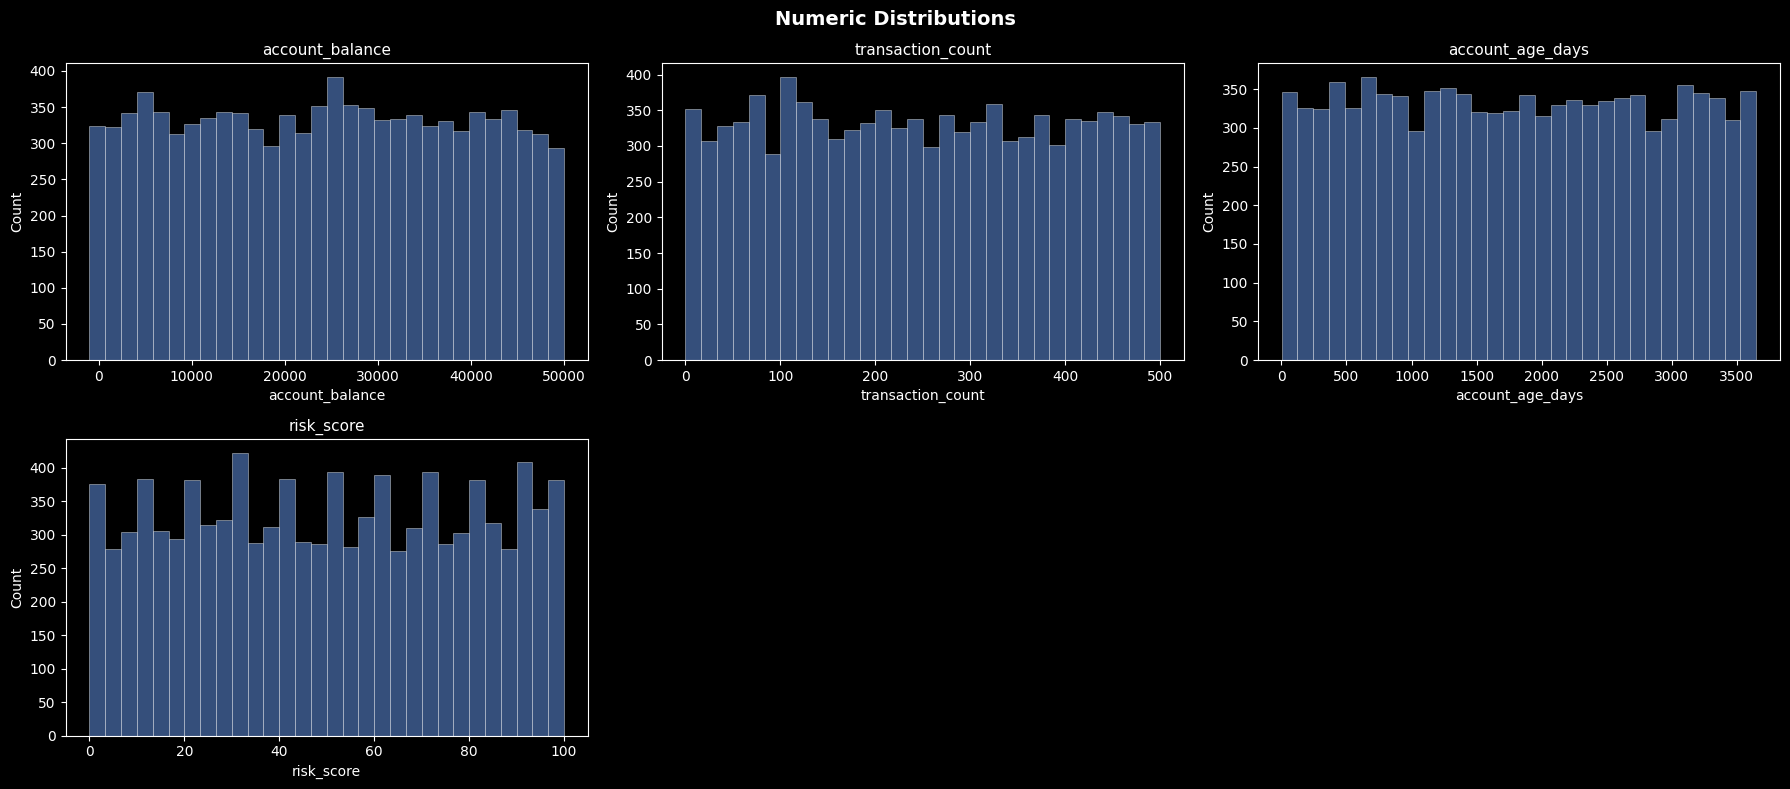

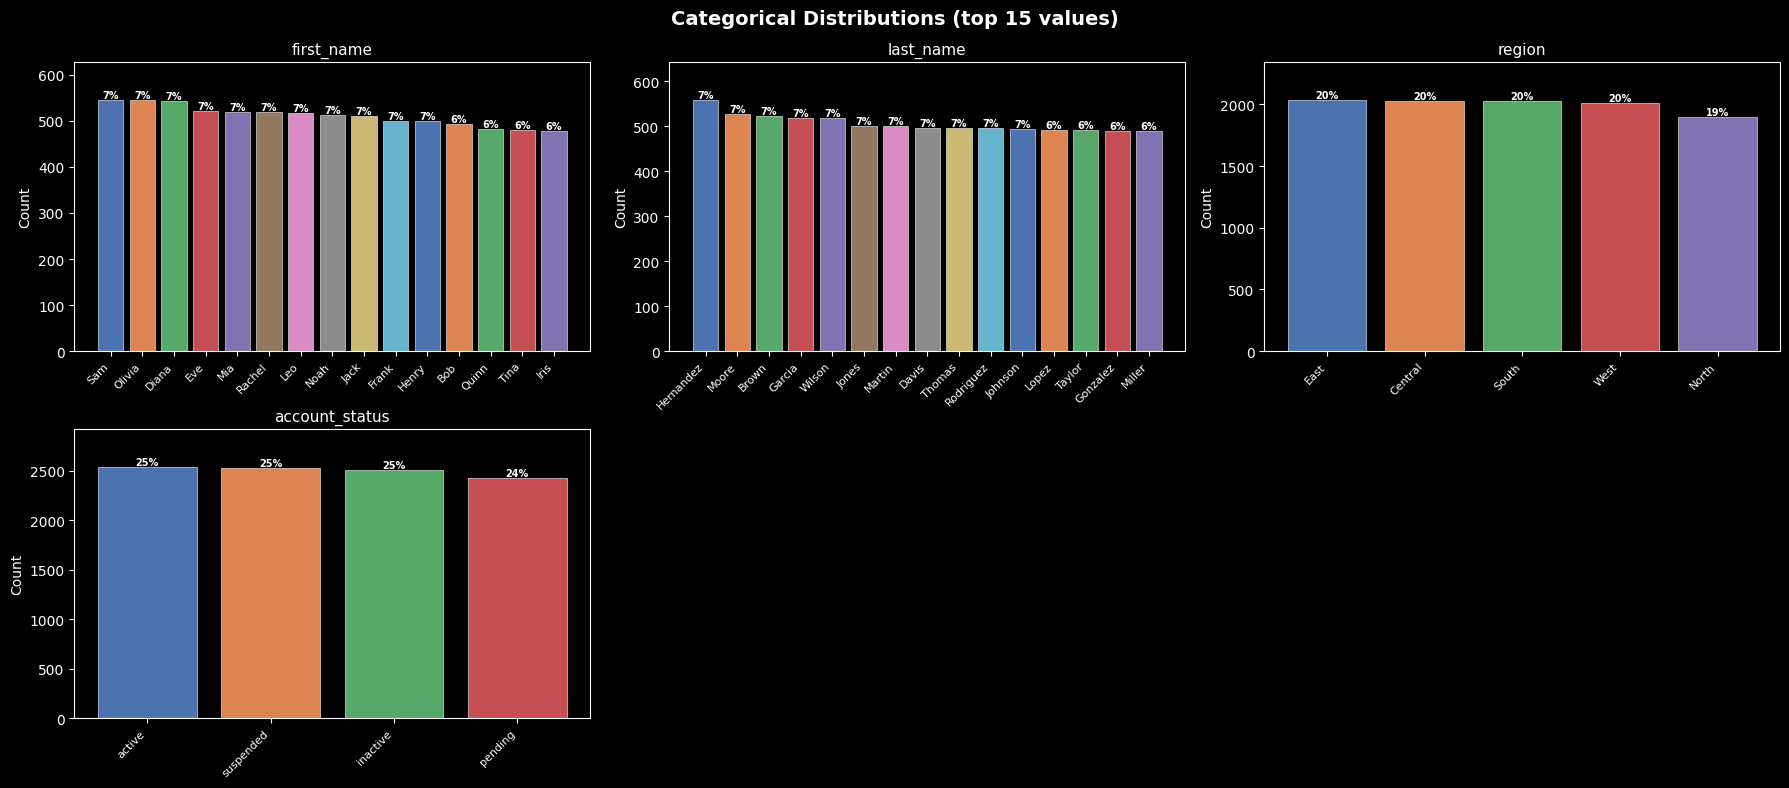

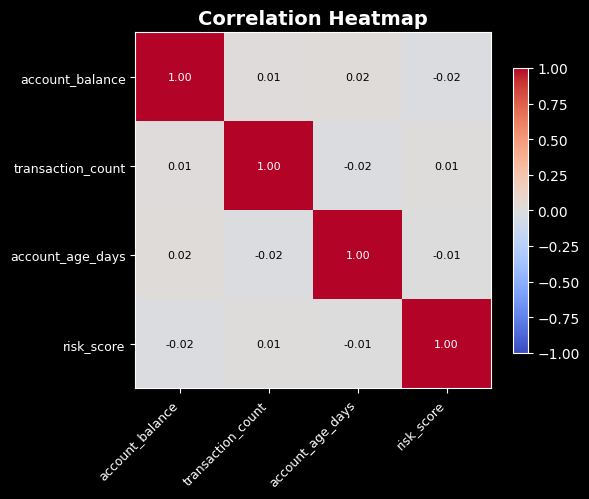

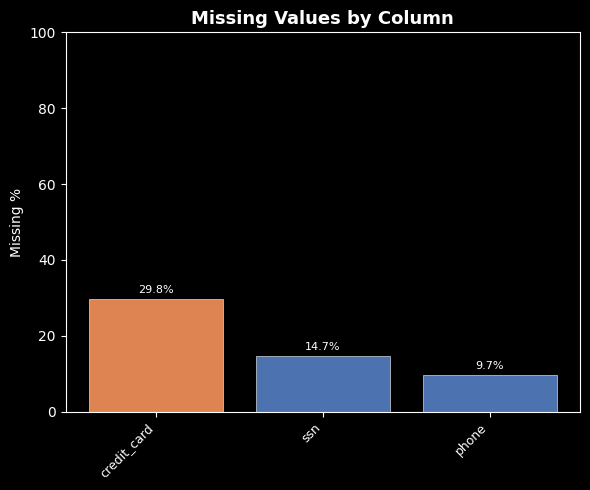

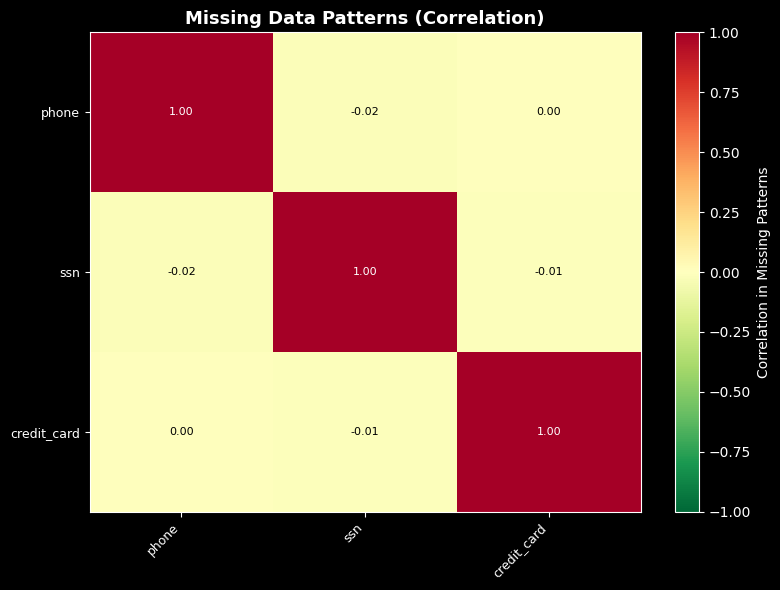

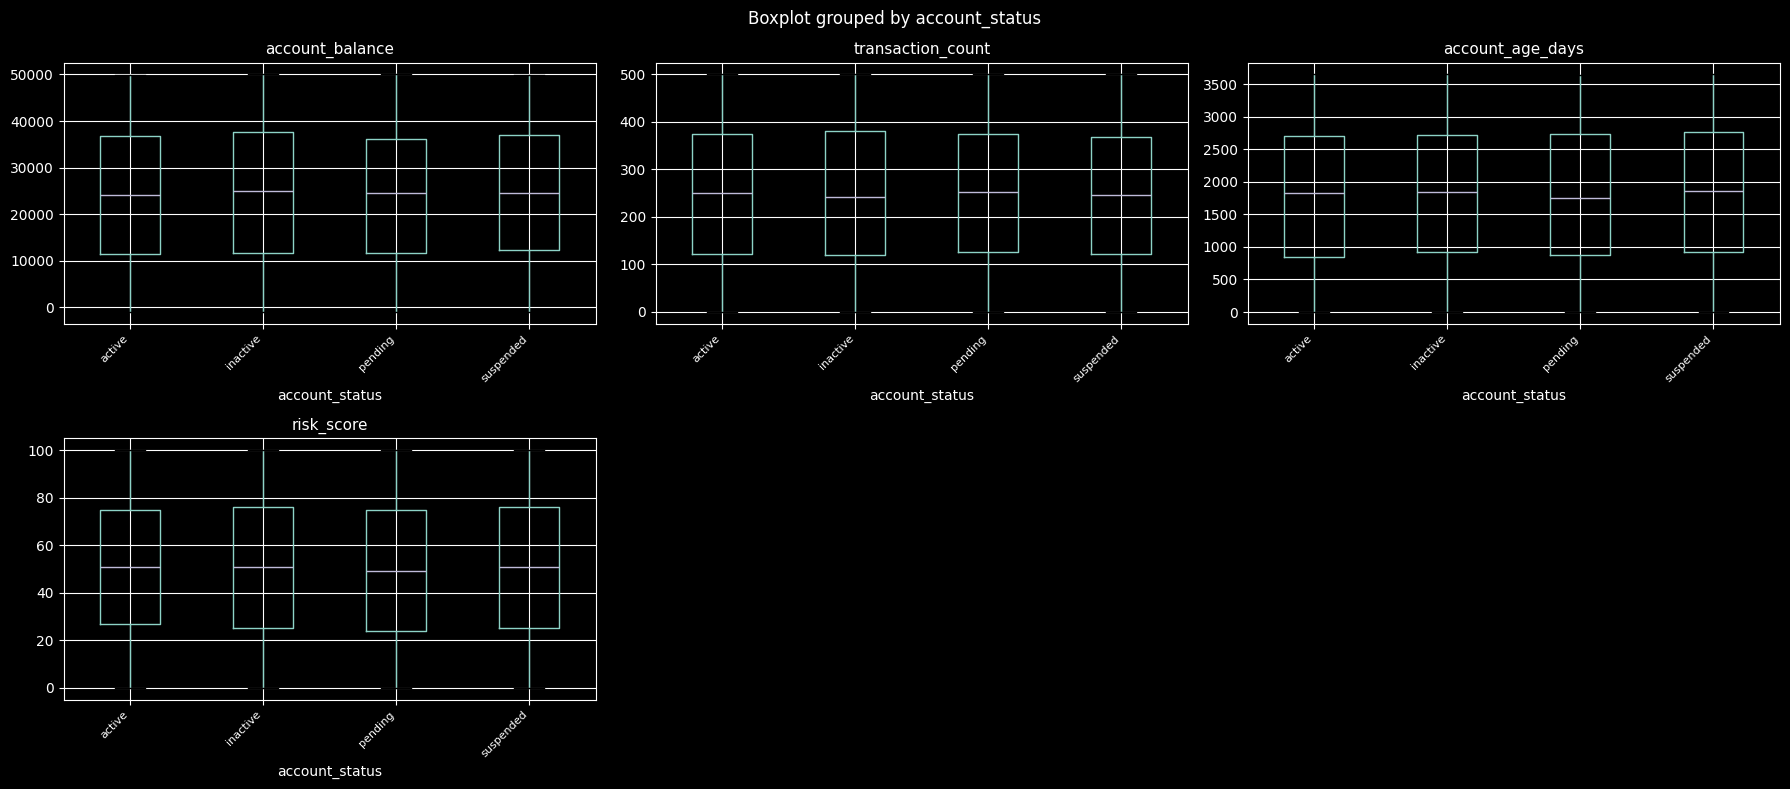

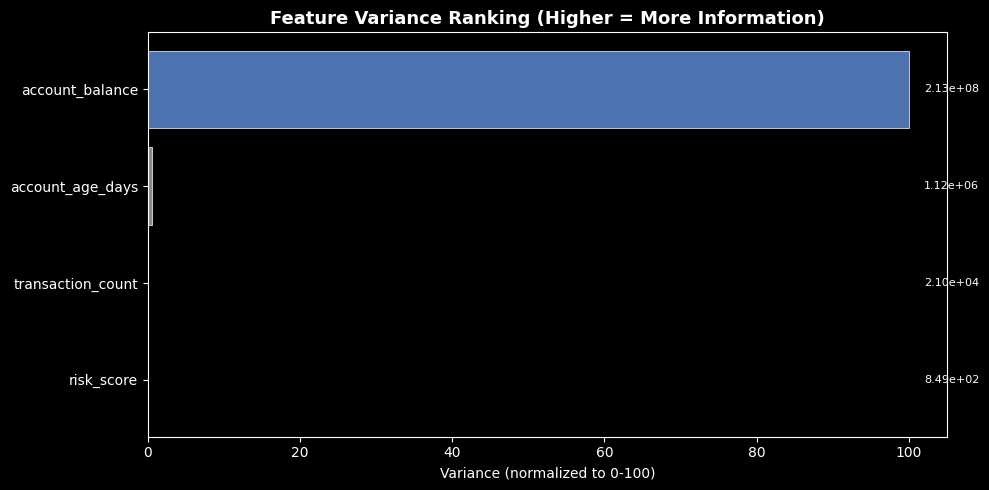

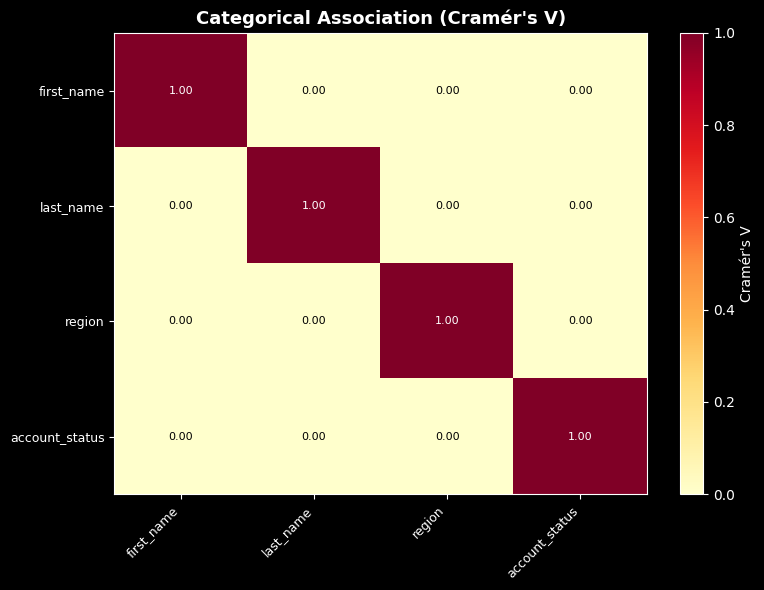

In [5]:
df.eda.vizall()

## 4. `df.eda.profile_column(column_name)` — Deep Dive Into One Column

Detailed analysis of a single column:
- Type detection with confidence score
- Distribution analysis (symmetric, skewed, etc.)
- Transformation recommendations (log, sqrt)
- Outlier analysis
- For categorical: value frequencies and cardinality

In [6]:
# Choose any column to profile
df.eda.profile_column('account_balance')


  Column Profile: account_balance

Type Information:
  Data Type       : float64
  Inferred Role   : numeric (confidence: 0.98)
  Unique Values   : 98950
  Missing         : 0 (0.0%)

Numeric Statistics:
  Mean            : 2.453e+04
  Median          : 2.458e+04
  Std Dev         : 1.468e+04
  Min             : -999.1
  Max             : 5e+04
  Q1 (25%)        : 1.18e+04
  Q3 (75%)        : 3.725e+04

Distribution:
  Shape           : Symmetric/Normal-like
  Skewness        : -0.005 (minimal skew)




## 5. `df.eda.compare(other_df)` — Detect Schema Drift

Compare two datasets to detect changes:
- Dimension changes (rows/columns added/removed)
- Score regression (quality, readiness, risk changes)
- Schema drift (column roles changed)
- New risk signals (PII, encoding)

In [7]:
# Example: Compare with a subset
df_subset = df.sample(frac=0.8, random_state=42)
df.eda.compare(df_subset)


  Dataset Comparison

Dataset Dimensions:
  Dataset 1 : 100,000 rows ×  16 columns
  Dataset 2 : 80,000 rows ×  16 columns
  Change    : -20,000 (-20.0%)

Score Changes:
  data_quality    :  92 →  92  +0  
  model_readiness :  76 →  76  +0  
  risk            :  70 →  70  +0  

PII Detection Changes:




---

# SECTION 2: The 10 One-Liner Methods (Interactive Exploration)

Quick methods that return DataFrames for interactive use. All support format options.

## Scores & Quality Metrics

In [8]:
# Data quality, model readiness, and risk scores
df.eda.scores_df()

,Value
data_quality,92
risk,70
model_readiness,76


In [9]:
# Show full insights (default)
insights = df.eda.insights_df()
print("Full Insights:")
print(insights)

# Or truncated for compact view
# print("\nTruncated Insights:")
# print(df.eda.insights_df(full_line=False))

Full Insights:
                                                                                                          Insight
0                           Likely identifier column(s) detected: customer_id. Consider excluding from modelling.
1             Column(s) with low cardinality (likely categorical): first_name, last_name, region, account_status.
2                  Datetime column(s) detected: last_transaction, signup_date. Temporal features may be valuable.
3                                                Minor missing values in: 'email', 'phone', 'ssn', 'credit_card'.
4                          PII detected in column 'email': 95017 email address(s). Mask or remove before sharing.
5                           PII detected in column 'phone': 89875 phone number(s). Mask or remove before sharing.
6                   PII detected in column 'ssn': 84941 Social Security Number(s). Mask or remove before sharing.
7   PII detected in column 'notes': 15851 email address(s), 15092 phone n

## Column Information

In [10]:
# Column roles, types, and confidence scores
df.eda.schema_df()

,Column,dtype,role,confidence,unique,uniqueness_ratio
0,customer_id,int64,id_candidate,0.95,100000,1.0
1,first_name,object,categorical,0.9,20,0.0002
2,last_name,object,categorical,0.9,20,0.0002
3,email,object,text,0.85,93202,0.932
4,phone,object,text,0.85,89875,0.8988
5,ssn,object,text,0.85,84941,0.8494
6,credit_card,float64,numeric,0.98,70227,0.7023
7,account_balance,float64,numeric,0.98,98950,0.9895
8,transaction_count,int64,numeric,0.98,501,0.005
9,account_age_days,int64,numeric,0.98,3650,0.0365


In [11]:
# Descriptive statistics per column
df.eda.stats_df()

,Column,dtype,count,missing,unique,mean,median,std,min,max,q25,q75,skewness,top_value,top_freq
0,customer_id,int64,100000,0,100000,1049999.5,1049999.5,28867.657797,1000000.0,1099999.0,1024999.75,1074999.25,0.0,NaN,NaN
1,first_name,object,100000,0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bob,5113
2,last_name,object,100000,0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wilson,5140
3,email,object,95017,4983,93202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tina.thomas662@outlook.com,3
4,phone,object,89875,10125,89875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,+1-963-543-6107,1
5,ssn,object,84941,15059,84941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295-44-6327,1
6,credit_card,float64,70227,29773,70227,4692755251501.008789,4797309948252.0,677006434707.039917,3400003428041.0,5599996285660.0,4170539481610.0,5300979159896.0,-0.439407,NaN,NaN
7,account_balance,float64,100000,0,98950,24526.367086,24575.525,14682.754135,-999.06,49999.59,11800.69,37253.82,-0.005011,NaN,NaN
8,transaction_count,int64,100000,0,501,249.5063,250.0,144.71618,0.0,500.0,124.0,375.0,0.001013,NaN,NaN
9,account_age_days,int64,100000,0,3650,1824.94238,1824.0,1053.275127,1.0,3650.0,915.0,2735.0,0.004625,NaN,NaN


## Data Quality Details

In [12]:
# Missing data - show as percentage (default)
print("Missing Data (Percentage):")
print(df.eda.missing_df())

# Or as counts
print("\nMissing Data (Counts):")
print(df.eda.missing_df(format='number'))

Missing Data (Percentage):


               Column Missing_Data
0         customer_id         0.0%
1          first_name         0.0%
2           last_name         0.0%
3               email         5.0%
4               phone        10.1%
5                 ssn        15.1%
6         credit_card        29.8%
7     account_balance         0.0%
8   transaction_count         0.0%
9    account_age_days         0.0%
10             region         0.0%
11     account_status         0.0%
12   last_transaction         0.0%
13              notes         0.0%
14        signup_date         0.0%
15         risk_score         0.0%

Missing Data (Counts):


               Column  Missing_Data
0         customer_id             0
1          first_name             0
2           last_name             0
3               email          4983
4               phone         10125
5                 ssn         15059
6         credit_card         29773
7     account_balance             0
8   transaction_count             0
9    account_age_days             0
10             region             0
11     account_status             0
12   last_transaction             0
13              notes             0
14        signup_date             0
15         risk_score             0


In [13]:
# Duplicate rows and constant columns
df.eda.duplicates_df()

,Metric,Value
0,Total Rows,100000
1,Duplicate Rows,0
2,Constant Columns,None


## Relationships & Anomalies

In [14]:
# Pearson correlation matrix
df.eda.correlation_df()

,customer_id,credit_card,account_balance,transaction_count,account_age_days,risk_score
customer_id,1.000000,-0.003239,0.000359,0.000427,0.001007,-0.000296
credit_card,-0.003239,1.000000,0.000983,-0.003361,0.003696,-0.005496
account_balance,0.000359,0.000983,1.000000,-0.003687,-0.000483,-0.004038
transaction_count,0.000427,-0.003361,-0.003687,1.000000,-0.000077,0.003074
account_age_days,0.001007,0.003696,-0.000483,-0.000077,1.000000,0.001801
risk_score,-0.000296,-0.005496,-0.004038,0.003074,0.001801,1.000000


In [15]:
# Outlier counts - show as counts (default)
print("Outliers (Counts):")
print(df.eda.outliers_df())

# Or as percentages
print("\nOutliers (Percentage):")
print(df.eda.outliers_df(format='percentage'))

Outliers (Counts):


              Column  Outliers
0        customer_id         0
1        credit_card         0
2    account_balance         0
3  transaction_count         0
4   account_age_days         0
5         risk_score         0

Outliers (Percentage):


              Column Outliers
0        customer_id     0.0%
1        credit_card     0.0%
2    account_balance     0.0%
3  transaction_count     0.0%
4   account_age_days     0.0%
5         risk_score     0.0%


## Security & Privacy

In [16]:
# PII detection (emails, phone numbers, etc.)
df.eda.pii_df()

,Column,PII_Type,Count
0,email,email,95017
1,phone,phone,89875
2,ssn,ssn,84941
3,notes,email,15851
4,notes,phone,15092


In [17]:
# Encoding detection (Base64, obfuscation)
df.eda.encoding_df()

,Column,Encoding_Type
0,region,possible_base64


---

# SECTION 3: The Plugin System (Custom Analysis Workflows)

Run specific plugins for lightweight, custom analysis. Useful when you only care about certain checks.

## How Plugins Work

The 5 powerful methods run all 8 plugins automatically. You can also run plugins manually for:
- Lightweight analysis (run only what you need)
- Custom workflows (combine built-in + your own plugins)
- Programmatic access to raw results

**Available Plugins:**
- `SchemaPlugin` — Column roles & types
- `StatsPlugin` — Descriptive statistics
- `MissingDataPlugin` — Missing value rates
- `DuplicatesPlugin` — Duplicate rows & constants
- `CorrelationPlugin` — Correlation matrix
- `OutlierPlugin` — Outlier counts
- `PIIDetectorPlugin` — PII findings
- `EncodingDetectionPlugin` — Encoding signals

## Example 1: Quick Data Quality Check

Run only the plugins that matter for data quality: missing data, duplicates, and outliers.

In [18]:
from noweda.core.engine import AutoEDAEngine
from noweda.plugins.missing import MissingDataPlugin
from noweda.plugins.duplicates import DuplicatesPlugin
from noweda.plugins.outliers import OutlierPlugin

# Create engine with only the plugins we need
engine = AutoEDAEngine([
    MissingDataPlugin(),
    DuplicatesPlugin(),
    OutlierPlugin(),
])

# Run analysis
report = engine.run_df(df)

# Access results
print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print("\n📊 MISSING DATA:")
missing = report['results']['missing']
for col, rate in missing.items():
    if rate > 0:
        print(f"  {col}: {rate*100:.1f}% missing")
if all(rate == 0 for rate in missing.values()):
    print("  ✓ No missing data")

print("\n🔄 DUPLICATES & CONSTANTS:")
dups = report['results']['duplicates']
print(f"  Duplicate rows: {dups['duplicate_rows']}")
print(f"  Constant columns: {dups['constant_columns'] or 'None'}")

print("\n⚠️  OUTLIERS:")
outliers = report['results']['outliers']
for col, count in outliers.items():
    if count > 0:
        pct = (count / len(df) * 100)
        print(f"  {col}: {count} outliers ({pct:.1f}%)")
if all(count == 0 for count in outliers.values()):
    print("  ✓ No outliers detected")

DATA QUALITY CHECK

📊 MISSING DATA:
  email: 5.0% missing
  phone: 10.1% missing
  ssn: 15.1% missing
  credit_card: 29.8% missing

🔄 DUPLICATES & CONSTANTS:
  Duplicate rows: 0
  Constant columns: None

⚠️  OUTLIERS:
  ✓ No outliers detected


## Example 2: Security & Privacy Scan

Check for PII and encoded data that might be sensitive.

In [19]:
from noweda.plugins.pii import PIIDetectorPlugin
from noweda.plugins.encoding import EncodingDetectionPlugin

# Create engine for security scanning
engine = AutoEDAEngine([
    PIIDetectorPlugin(),
    EncodingDetectionPlugin(),
])

report = engine.run_df(df)

print("=" * 70)
print("SECURITY & PRIVACY SCAN")
print("=" * 70)

print("\n🔐 PII DETECTED:")
pii = report['results']['pii']
if pii:
    for col, findings in pii.items():
        print(f"  ⚠️  {col}: {findings}")
else:
    print("  ✓ No PII detected")

print("\n🔒 ENCODING SIGNALS:")
encoding = report['results']['encoding']
if encoding:
    for col, signal in encoding.items():
        print(f"  ⚠️  {col}: {signal}")
else:
    print("  ✓ No encoding detected")

SECURITY & PRIVACY SCAN

🔐 PII DETECTED:
  ⚠️  email: {'email': 95017}
  ⚠️  phone: {'phone': 89875}
  ⚠️  ssn: {'ssn': 84941}
  ⚠️  notes: {'email': 15851, 'phone': 15092}

🔒 ENCODING SIGNALS:
  ⚠️  region: possible_base64


## Example 3: Lightweight Schema & Stats Analysis

Understand data types and basic statistics without running all plugins.

In [20]:
from noweda.plugins.schema import SchemaPlugin
from noweda.plugins.stats import StatsPlugin

# Create lightweight engine
engine = AutoEDAEngine([
    SchemaPlugin(),
    StatsPlugin(),
])

report = engine.run_df(df)

print("=" * 70)
print("SCHEMA & STATISTICS")
print("=" * 70)

print("\n📋 COLUMN SCHEMA:")
schema = report['results']['schema']
for col, info in schema.items():
    role = info['role']
    conf = info['confidence']
    print(f"  {col:20} {role:15} (confidence: {conf:.2f})")

print("\n📊 STATISTICS (Numeric Columns):")
stats = report['results']['stats']
for col, info in stats.items():
    # Only show numeric columns
    if 'mean' in info and not pd.isna(info['mean']):
        print(f"  {col}:")
        print(f"    Mean: {info['mean']:.2f}, Std: {info['std']:.2f}")
        print(f"    Range: [{info['min']:.2f}, {info['max']:.2f}]")

SCHEMA & STATISTICS

📋 COLUMN SCHEMA:
  customer_id          id_candidate    (confidence: 0.95)
  first_name           categorical     (confidence: 0.90)
  last_name            categorical     (confidence: 0.90)
  email                text            (confidence: 0.85)
  phone                text            (confidence: 0.85)
  ssn                  text            (confidence: 0.85)
  credit_card          numeric         (confidence: 0.98)
  account_balance      numeric         (confidence: 0.98)
  transaction_count    numeric         (confidence: 0.98)
  account_age_days     numeric         (confidence: 0.98)
  region               categorical     (confidence: 0.90)
  account_status       categorical     (confidence: 0.90)
  last_transaction     datetime        (confidence: 0.85)
  notes                text            (confidence: 0.85)
  signup_date          datetime        (confidence: 0.85)
  risk_score           numeric         (confidence: 0.98)

📊 STATISTICS (Numeric Columns):
 

## Example 4: Write Your Own Custom Plugin

Create a custom plugin to add domain-specific analysis.

In [21]:
from noweda.plugins.base import BasePlugin

class HighCardinalityPlugin(BasePlugin):
    """Flag columns with very high cardinality (many unique values)."""
    name = "high_cardinality"

    def run(self, df):
        results = {}
        for col in df.columns:
            unique_ratio = df[col].nunique() / len(df)
            if unique_ratio > 0.95:  # >95% unique values
                results[col] = {
                    'unique_ratio': unique_ratio,
                    'warning': 'Very high cardinality - may be ID or quasi-ID column'
                }
        return results

# Use the custom plugin
custom_plugin = HighCardinalityPlugin()
engine = AutoEDAEngine([custom_plugin])
report = engine.run_df(df)

print("=" * 70)
print("HIGH CARDINALITY CHECK (Custom Plugin)")
print("=" * 70)

results = report['results']['high_cardinality']
if results:
    for col, info in results.items():
        print(f"\n⚠️  {col}")
        print(f"   Unique ratio: {info['unique_ratio']:.1%}")
        print(f"   {info['warning']}")
else:
    print("\n✓ No high-cardinality columns found")

HIGH CARDINALITY CHECK (Custom Plugin)

⚠️  customer_id
   Unique ratio: 100.0%
   Very high cardinality - may be ID or quasi-ID column

⚠️  account_balance
   Unique ratio: 99.0%
   Very high cardinality - may be ID or quasi-ID column

⚠️  last_transaction
   Unique ratio: 100.0%
   Very high cardinality - may be ID or quasi-ID column

⚠️  signup_date
   Unique ratio: 100.0%
   Very high cardinality - may be ID or quasi-ID column


## Example 5: Combine Built-in & Custom Plugins

Mix built-in plugins with your custom ones for a tailored workflow.

In [22]:
# Create engine with mix of built-in and custom
engine = AutoEDAEngine([
    SchemaPlugin(),
    MissingDataPlugin(),
    custom_plugin,  # Our custom plugin from above
])

report = engine.run_df(df)

print("=" * 70)
print("COMBINED ANALYSIS")
print("=" * 70)

# Show schema
print("\n📋 SCHEMA:")
for col, info in report['results']['schema'].items():
    print(f"  {col}: {info['role']}")

# Show missing data
print("\n📊 MISSING DATA:")
for col, rate in report['results']['missing'].items():
    if rate > 0:
        print(f"  {col}: {rate*100:.1f}%")

# Show high cardinality warnings
print("\n⚠️  HIGH CARDINALITY:")
if report['results']['high_cardinality']:
    for col in report['results']['high_cardinality'].keys():
        print(f"  {col}")
else:
    print("  None")

COMBINED ANALYSIS

📋 SCHEMA:
  customer_id: id_candidate
  first_name: categorical
  last_name: categorical
  email: text
  phone: text
  ssn: text
  credit_card: numeric
  account_balance: numeric
  transaction_count: numeric
  account_age_days: numeric
  region: categorical
  account_status: categorical
  last_transaction: datetime
  notes: text
  signup_date: datetime
  risk_score: numeric

📊 MISSING DATA:
  email: 5.0%
  phone: 10.1%
  ssn: 15.1%
  credit_card: 29.8%

⚠️  HIGH CARDINALITY:
  customer_id
  account_balance
  last_transaction
  signup_date


---

## Extended Example: New PII Patterns

NowEDA now detects four types of PII:
- **Email**: Standard email format
- **Phone**: US and international formats (including +1, dashes, spaces, parentheses)
- **SSN**: Social Security Numbers (123-45-6789 or 123 45 6789)
- **Credit Card**: Visa, Mastercard, Amex, Discover with Luhn algorithm validation

In [23]:
# Create a dataset with multiple PII types
import pandas as pd

df_pii = pd.DataFrame({
    'customer_id': ['CUST001', 'CUST002', 'CUST003', 'CUST004'],
    'email': ['alice@company.com', 'bob@example.org', 'charlie.brown@mail.com', 'diana@test.net'],
    'phone': ['(555) 123-4567', '+1-800-555-0100', '555.987.6543', '(212) 555-1234'],
    'ssn': ['123-45-6789', '987-65-4320', '555-12-3456', 'N/A'],
    'credit_card': ['4532015112830366', '5425233430109903', '378282246310005', 'XXXXXXXXXXXX'],
    'notes': ['Good customer', 'Call 555-1234 for follow-up', 'Email: test@test.com', 'No notes'],
})

print("DataFrame with multiple PII types:")
print(df_pii)

print("\n" + "="*70)
print("PII DETECTION RESULTS")
print("="*70)

pii_results = df_pii.eda.pii_df()
print(pii_results)

print("\nPII Summary:")
for pii_type in pii_results['PII_Type'].unique():
    count = pii_results[pii_results['PII_Type'] == pii_type]['Count'].sum()
    columns = pii_results[pii_results['PII_Type'] == pii_type]['Column'].tolist()
    print(f"  {pii_type.upper()}: {count} instances in columns {columns}")

DataFrame with multiple PII types:
  customer_id                   email            phone          ssn  \
0     CUST001       alice@company.com   (555) 123-4567  123-45-6789   
1     CUST002         bob@example.org  +1-800-555-0100  987-65-4320   
2     CUST003  charlie.brown@mail.com     555.987.6543  555-12-3456   
3     CUST004          diana@test.net   (212) 555-1234          N/A   

        credit_card                        notes  
0  4532015112830366                Good customer  
1  5425233430109903  Call 555-1234 for follow-up  
2   378282246310005         Email: test@test.com  
3      XXXXXXXXXXXX                     No notes  

PII DETECTION RESULTS


        Column     PII_Type  Count
0        email        email      4
1        phone        phone      4
2          ssn          ssn      3
3  credit_card  credit_card      3
4        notes        email      1

PII Summary:
  EMAIL: 5 instances in columns ['email', 'notes']
  PHONE: 4 instances in columns ['phone']
  SSN: 3 instances in columns ['ssn']
  CREDIT_CARD: 3 instances in columns ['credit_card']


---

## Extended Example: Chunked Ingestion for Large Files

Use `eda.read_chunked()` to process large CSV/JSON files without loading them entirely into memory. Spark is used automatically for supported large files, and NowEDA shows a loading indicator while the work runs.

In [24]:
# Example 1: Read a large file all at once (Spark may be used internally)
import tempfile
import os

# Create a sample large CSV
tmp = tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w')
tmp.write('id,name,value,status\n')
for i in range(100):
    tmp.write(f'{i},record_{i},{i*100},active\n')
tmp.close()

print(f"Created test file: {tmp.name}")
print(f"File size: {os.path.getsize(tmp.name)} bytes")

# Read in chunks, but get a single concatenated DataFrame
df_large = eda.read_chunked(tmp.name, chunksize=20)
print(f"\nLoaded DataFrame: {df_large.shape}")
print(df_large.head())

# Run analysis on the concatenated result
print("\nQuick stats:")
print(df_large.eda.scores_df())

Created test file: /var/folders/pd/gcm9nctx4ng89fh5f7tp3n600000gn/T/tmp83nq2r4t.csv
File size: 2489 bytes



Loaded DataFrame: (100, 4)
   id      name  value  status
0   0  record_0      0  active
1   1  record_1    100  active
2   2  record_2    200  active
3   3  record_3    300  active
4   4  record_4    400  active

Quick stats:


                 Value
data_quality        97
risk                 0
model_readiness     95


In [25]:
# Example 2: Process chunks one at a time (Spark or pandas chunking as needed)
print("Processing file in chunks (concat=False):")
print("="*70)

chunk_count = 0
total_rows = 0
pii_findings_all = []

# Iterate through chunks
for chunk in eda.read_chunked(tmp.name, chunksize=20, concat=False):
    chunk_count += 1
    total_rows += len(chunk)
    
    print(f"\nChunk {chunk_count}: {chunk.shape}")
    print(f"  Columns: {list(chunk.columns)}")
    print(f"  First row: {chunk.iloc[0].to_dict()}")
    
    # Analyze this chunk
    chunk_pii = chunk.eda.pii_df()
    if len(chunk_pii) > 0:
        pii_findings_all.append(chunk_pii)

print(f"\n" + "="*70)
print(f"Processed {chunk_count} chunks, {total_rows} total rows")
print(f"Memory efficient: Only one chunk in memory at a time")

# Cleanup
os.unlink(tmp.name)
print("\n✓ Cleanup complete")

Processing file in chunks (concat=False):



Chunk 1: (20, 4)
  Columns: ['id', 'name', 'value', 'status']
  First row: {'id': 0, 'name': 'record_0', 'value': 0, 'status': 'active'}



Chunk 2: (20, 4)
  Columns: ['id', 'name', 'value', 'status']
  First row: {'id': 20, 'name': 'record_20', 'value': 2000, 'status': 'active'}



Chunk 3: (20, 4)
  Columns: ['id', 'name', 'value', 'status']
  First row: {'id': 40, 'name': 'record_40', 'value': 4000, 'status': 'active'}



Chunk 4: (20, 4)
  Columns: ['id', 'name', 'value', 'status']
  First row: {'id': 60, 'name': 'record_60', 'value': 6000, 'status': 'active'}



Chunk 5: (20, 4)
  Columns: ['id', 'name', 'value', 'status']
  First row: {'id': 80, 'name': 'record_80', 'value': 8000, 'status': 'active'}



Processed 5 chunks, 100 total rows
Memory efficient: Only one chunk in memory at a time

✓ Cleanup complete


---

## Advanced: Chunked Ingestion Techniques

The test dataset `test_data_large_with_pii.csv` (100,000 rows, 19.5 MB) is perfect for demonstrating streaming ingestion.

In [26]:
import noweda as eda
import pandas as pd

# Path to the test dataset (100,000 rows with PII)
TEST_FILE = 'test_data_large_with_pii.csv'

print(f"File size: {os.path.getsize(TEST_FILE) / (1024**2):.2f} MB")
print(f"This file is large enough to benefit from chunked reading")
print()

File size: 19.49 MB
This file is large enough to benefit from chunked reading



### Technique 1: Load All Chunks, Return Single DataFrame

Best for: Data that fits in RAM, but you want to control chunking for performance.

In [27]:
# Read 100k rows in 10k-row chunks, automatically concatenate
print("Loading full dataset in chunks (Spark may be used automatically)...")
df_chunked = eda.read_chunked(TEST_FILE, chunksize=10_000)

print(f"✓ Loaded {len(df_chunked):,} rows × {len(df_chunked.columns)} columns")
print(f"✓ Memory usage: {df_chunked.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
print(f"\nShape: {df_chunked.shape}")
print(f"Columns: {list(df_chunked.columns)}")
print(f"\nFirst row:")
print(df_chunked.iloc[0])

Loading full dataset in chunks (Spark may be used automatically)...


✓ Loaded 100,000 rows × 16 columns
✓ Memory usage: 72.96 MB

Shape: (100000, 16)
Columns: ['customer_id', 'first_name', 'last_name', 'email', 'phone', 'ssn', 'credit_card', 'account_balance', 'transaction_count', 'account_age_days', 'region', 'account_status', 'last_transaction', 'notes', 'signup_date', 'risk_score']

First row:
customer_id                                                        1000000
first_name                                                            Noah
last_name                                                         Martinez
email                                         noah.martinez956@company.com
phone                                                      +1-963-543-6107
ssn                                                            295-44-6327
credit_card                                                            NaN
account_balance                                                    7169.27
transaction_count                                                    

### Technique 2: Stream Chunks One-at-a-Time

Best for: Files too large for RAM, or when you need to process/aggregate per-chunk.

In [28]:
# Process chunks without loading the entire file
print("Streaming chunks (concat=False):")
print("Spark can accelerate the read before pandas yields each chunk.")
print("="*70)

chunk_metrics = []
total_rows = 0

for i, chunk in enumerate(eda.read_chunked(TEST_FILE, chunksize=25_000, concat=False), 1):
    total_rows += len(chunk)
    
    # Run analysis on this chunk
    scores = chunk.eda.scores_df().T
    scores['chunk'] = i
    chunk_metrics.append(scores)
    
    print(f"Chunk {i}: {len(chunk):,} rows")
    print(f"  Data Quality: {scores['data_quality'].iloc[0]:.1f}")
    print(f"  Model Readiness: {scores['model_readiness'].iloc[0]:.1f}")
    print(f"  Risk Score: {scores['risk'].iloc[0]:.1f}")

print(f"\nTotal: {total_rows:,} rows processed in {i} chunks")
print(f"Memory-efficient: Only ~{len(pd.read_csv(TEST_FILE, nrows=25000)) * 16 / (1024**2):.1f} MB per chunk in memory")

Streaming chunks (concat=False):
Spark can accelerate the read before pandas yields each chunk.


Chunk 1: 25,000 rows
  Data Quality: 92.0
  Model Readiness: 76.0
  Risk Score: 70.0


Chunk 2: 25,000 rows
  Data Quality: 92.0
  Model Readiness: 76.0
  Risk Score: 80.0


Chunk 3: 25,000 rows
  Data Quality: 92.0
  Model Readiness: 76.0
  Risk Score: 70.0


Chunk 4: 25,000 rows
  Data Quality: 89.0
  Model Readiness: 71.0
  Risk Score: 70.0

Total: 100,000 rows processed in 4 chunks
Memory-efficient: Only ~0.4 MB per chunk in memory


### Technique 3: PII Detection Across Large Dataset

Detect and collect PII from all chunks.

In [29]:
# Aggregate PII findings across all chunks
print("PII Detection Across Chunks:")
print("="*70)

pii_by_chunk = {}
all_pii = []

for i, chunk in enumerate(eda.read_chunked(TEST_FILE, chunksize=20_000, concat=False), 1):
    chunk_pii = chunk.eda.pii_df()
    
    if len(chunk_pii) > 0:
        chunk_pii['chunk_num'] = i
        all_pii.append(chunk_pii)
        
        # Summary for this chunk
        total = chunk_pii['Count'].sum()
        pii_by_chunk[i] = total
        print(f"Chunk {i}: {total:,} PII instances")
    else:
        pii_by_chunk[i] = 0
        print(f"Chunk {i}: No PII detected")

# Combine all PII findings
if all_pii:
    combined_pii = pd.concat(all_pii, ignore_index=True)
    print(f"\nTotal PII instances found: {combined_pii['Count'].sum():,}")
    print(f"\nPII Breakdown:")
    summary = combined_pii.groupby('PII_Type')['Count'].sum().sort_values(ascending=False)
    print(summary)
else:
    print("No PII detected in any chunk")

PII Detection Across Chunks:


Chunk 1: 60,089 PII instances


Chunk 2: 60,384 PII instances


Chunk 3: 60,113 PII instances


Chunk 4: 60,035 PII instances


Chunk 5: 60,155 PII instances

Total PII instances found: 300,776

PII Breakdown:
PII_Type
email    110868
phone    104967
ssn       84941
Name: Count, dtype: int64


### Technique 4: Custom Delimiter (Pipe-Separated Values)

Forward `sep` parameter for non-standard delimiters.

In [30]:
# Example: If you had a pipe-delimited file
# df = eda.read_chunked('data.csv', chunksize=10_000, sep='|')

# For JSON files with newline-delimited records
# df = eda.read_chunked('data.jsonl', chunksize=10_000)

# TSV files (tab-separated) - detected automatically by extension
# df = eda.read_chunked('data.tsv', chunksize=10_000)

# With additional pandas parameters
# df = eda.read_chunked('data.csv', chunksize=10_000, dtype={'col1': 'int32'}, na_values=['NA', 'N/A'])

print("\nSupported formats for chunked reading:")
print("  (Spark is used automatically for supported large files)")
print("  ✓ .csv, .tsv, .tab, .txt — Delimited text")
print("  ✓ .json, .jsonl — JSON and newline-delimited JSON")
print("\nNot supported (use eda.read() instead):")
print("  ✗ .xlsx, .xls — Excel")
print("  ✗ .parquet — Parquet")
print("  ✗ .xml, .html — XML/HTML")
print("  ✗ .h5, .hdf5 — HDF5")


Supported formats for chunked reading:
  (Spark is used automatically for supported large files)
  ✓ .csv, .tsv, .tab, .txt — Delimited text
  ✓ .json, .jsonl — JSON and newline-delimited JSON

Not supported (use eda.read() instead):
  ✗ .xlsx, .xls — Excel
  ✗ .parquet — Parquet
  ✗ .xml, .html — XML/HTML
  ✗ .h5, .hdf5 — HDF5


### Memory Usage Comparison

How chunked reading reduces memory footprint on large files:

In [31]:
import os
import psutil

file_path = TEST_FILE
file_size_mb = os.path.getsize(file_path) / (1024**2)

print(f"File on disk: {file_size_mb:.2f} MB")
print()

# Method 1: Load all at once (what eda.read() does, with Spark acceleration when applicable)
df_all = pd.read_csv(file_path)
mem_all = df_all.memory_usage(deep=True).sum() / (1024**2)
print(f"eda.read() — Load entire file (Spark-accelerated when large):")
print(f"  In-memory size: {mem_all:.2f} MB")
print(f"  Peak memory: ~{mem_all * 2:.2f} MB (parsing overhead)")
del df_all
print()

# Method 2: Chunked reading (concat=True; Spark-backed when supported)
df_chunked = eda.read_chunked(file_path, chunksize=10_000)
mem_chunked = df_chunked.memory_usage(deep=True).sum() / (1024**2)
print(f"eda.read_chunked(concat=True) — Load & concatenate (Spark-backed when large):")
print(f"  In-memory size: {mem_chunked:.2f} MB")
print(f"  Peak memory: ~{mem_chunked + 2:.2f} MB (chunking overhead minimal)")
del df_chunked
print()

# Method 3: Streaming chunks (concat=False)
print(f"eda.read_chunked(concat=False) — Stream one chunk at a time (Spark-backed when large):")
chunk_size_mb = 0
for chunk in eda.read_chunked(file_path, chunksize=10_000, concat=False):
    chunk_mem = chunk.memory_usage(deep=True).sum() / (1024**2)
    chunk_size_mb = max(chunk_size_mb, chunk_mem)
    break  # Just show first chunk size

print(f"  In-memory size: {chunk_size_mb:.2f} MB (one chunk at a time)")
print(f"  Peak memory: ~{chunk_size_mb:.2f} MB (minimal)")
print()

print("="*70)
print(f"For 1 GB files, streaming can reduce peak memory by 50-90%")
print(f"For 100 GB files, streaming is essential (no single-load possible)")

File on disk: 19.49 MB

eda.read() — Load entire file (Spark-accelerated when large):
  In-memory size: 72.96 MB
  Peak memory: ~145.92 MB (parsing overhead)



eda.read_chunked(concat=True) — Load & concatenate (Spark-backed when large):
  In-memory size: 72.96 MB
  Peak memory: ~74.96 MB (chunking overhead minimal)

eda.read_chunked(concat=False) — Stream one chunk at a time (Spark-backed when large):


  In-memory size: 7.30 MB (one chunk at a time)
  Peak memory: ~7.30 MB (minimal)

For 1 GB files, streaming can reduce peak memory by 50-90%
For 100 GB files, streaming is essential (no single-load possible)
